<a href="https://colab.research.google.com/github/yuniecorn-dev/esaa_assignment2/blob/main/ESAA_OB_WEEK6_study_1009.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##2.4 파이토치 코드 맛보기

- price: 자동차 가격
- maint: 자동차 유지 비용
- doors: 자동차 문 개수
- persons: 수용 인원
- lug_capacity: 수하물 용량
- safety: 안전성
- output: 차 상태

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
cols = ['price', 'maint', 'doors', 'persons', 'lug_capacity', 'safety', 'output']
dataset = pd.read_csv('car.data', names=cols)
display(dataset.head())

,price,maint,doors,persons,lug_capacity,safety,output
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


<Axes: ylabel='count'>

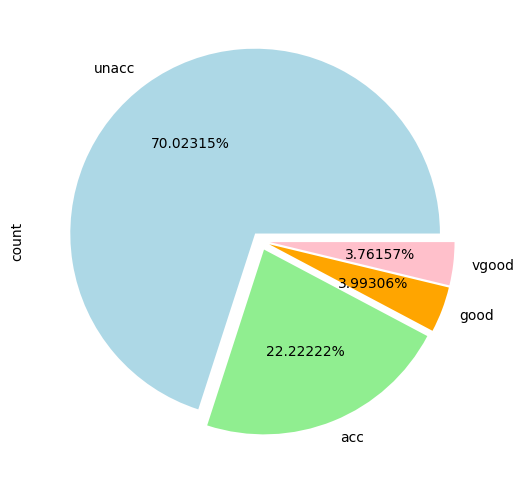

In [4]:
fig_size = plt.rcParams['figure.figsize']
fig_size[0] = 8
fig_size[1] = 6
plt.rcParams['figure.figsize'] = fig_size
dataset.output.value_counts().plot(kind='pie', autopct='%0.05f%%',
                                   colors=['lightblue', 'lightgreen', 'orange', 'pink'], explode=(0.05, 0.05, 0.05, 0.05))

- 양호한 상태의 자동차 비율이 매우 낮음.

In [7]:
# 데이터를 범주형 타입으로 변환
categorical_columns = ['price', 'maint', 'doors', 'persons', 'lug_capacity', 'safety']

for category in categorical_columns:
  dataset[category] = dataset[category].astype('category')

price = dataset['price'].cat.codes.values
maint = dataset['maint'].cat.codes.values
doors = dataset['doors'].cat.codes.values
persons = dataset['persons'].cat.codes.values
lug_capacity = dataset['lug_capacity'].cat.codes.values
safety = dataset['safety'].cat.codes.values

categorical_data = np.stack([price, maint, doors, persons, lug_capacity, safety], 1)
categorical_data[:10]

array([[3, 3, 0, 0, 2, 1],
       [3, 3, 0, 0, 2, 2],
       [3, 3, 0, 0, 2, 0],
       [3, 3, 0, 0, 1, 1],
       [3, 3, 0, 0, 1, 2],
       [3, 3, 0, 0, 1, 0],
       [3, 3, 0, 0, 0, 1],
       [3, 3, 0, 0, 0, 2],
       [3, 3, 0, 0, 0, 0],
       [3, 3, 0, 1, 2, 1]], dtype=int8)

- 범주형 데이터를 텐서로 변환하기 위한 절차
  - 범주형 데이터 → dataset[category] → 넘파이 배열(NumPy array) → 텐서(Tensor)
- cat.codes
  - 범주형 데이터(단어) → 숫자(넘파이 배열)로 변환
- np.stack
  - 두 개 이상의 넘파이 객체를 합칠 때 사용
  - 배열을 새로운 축으로 합쳐 줌.
  - 두 배열의 차원이 동일해야 함.
  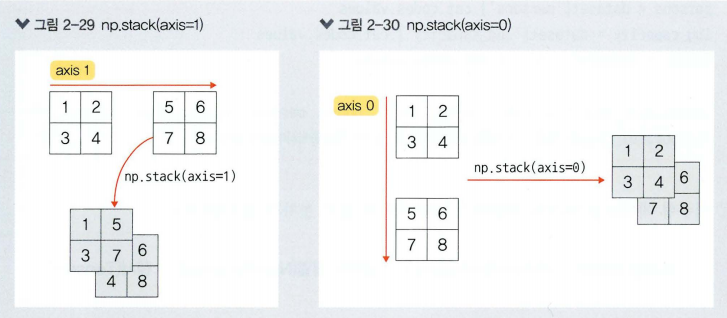
- np.concatenate
  - 선택한 축(axis)을 기준으로 두 개의 배열을 연결
  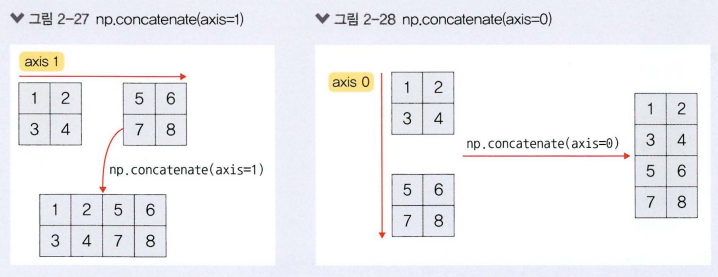

In [8]:
# 배열을 텐서로 변환
categorical_data = torch.tensor(categorical_data, dtype=torch.int64)
categorical_data[:10]

tensor([[3, 3, 0, 0, 2, 1],
        [3, 3, 0, 0, 2, 2],
        [3, 3, 0, 0, 2, 0],
        [3, 3, 0, 0, 1, 1],
        [3, 3, 0, 0, 1, 2],
        [3, 3, 0, 0, 1, 0],
        [3, 3, 0, 0, 0, 1],
        [3, 3, 0, 0, 0, 2],
        [3, 3, 0, 0, 0, 0],
        [3, 3, 0, 1, 2, 1]])

In [9]:
# 레이블로 사용할 칼럼을 텐서로 변환
outputs = pd.get_dummies(dataset.output)
outputs = outputs.values
outputs = torch.tensor(outputs).flatten()

print(categorical_data.shape)
print(outputs.shape)

torch.Size([1728, 6])
torch.Size([6912])


- get_dummies()
  - 가변수로 만들어 주는 함수
  - 문자를 숫자 (0,1)로 바꾸어 준다.
- ravel(), reshape(), flatten()
  - 텐서의 차원을 바꿀 때 사용

- 워드 임베딩
  - 유사한 단어끼리 유사하게 인코딩되도록 표현하는 방법
  - 높은 차원의 임베딩일수록 단어 간의 세부적인 관계를 잘 파악할 수 있음.
  - 단일 숫자로 변환된 넘파이 배열을 N차원으로 변경하여 사용

In [10]:
# 범주형 칼럼을 N차원으로 변환
categorical_column_sizes = [len(dataset[column].cat.categories) for column in categorical_columns]
categorical_embedding_sizes = [(col_size, min(50, (col_size+1)//2)) for col_size in categorical_column_sizes]
print(categorical_embedding_sizes)

[(4, 2), (4, 2), (4, 2), (3, 2), (3, 2), (3, 2)]


In [11]:
# 데이터셋 분리
total_records = 1728
test_records = int(total_records * .2)

categorical_train_data = categorical_data[:total_records - test_records]
categorical_test_data = categorical_data[total_records - test_records:total_records]
train_outputs = outputs[:total_records - test_records]
test_outputs = outputs[total_records - test_records:total_records]

In [12]:
# 데이터셋 분리 확인
print(len(categorical_train_data))
print(len(train_outputs))
print(len(categorical_test_data))
print(len(test_outputs))

1383
1383
345
345


In [34]:
# 모델의 네트워크 생성
class Model(nn.Module):
  def __init__(self, embedding_size, output_size, layers, p=0.4):
    super().__init__()
    self.all_embeddings = nn.ModuleList([nn.Embedding(ni, nf) for ni,
                                         nf in embedding_size])
    self.embedding_dropout = nn.Dropout(p)

    all_layers = []
    num_categorical_cols = sum((nf for ni, nf in embedding_size))
    input_size = num_categorical_cols

    for i in layers:
      all_layers.append(nn.Linear(input_size, i))
      all_layers.append(nn.ReLU(inplace=True)) # 활성화 함수
      all_layers.append(nn.BatchNorm1d(i)) # 배치 정규화 용도
      all_layers.append(nn.Dropout(p)) # 과적합 방지
      input_size = i

    all_layers.append(nn.Linear(layers[-1], output_size))
    self.layers = nn.Sequential(*all_layers)

  def forward(self, x_categorical):
    embeddings = []
    for i, e in enumerate(self.all_embeddings):
      embeddings.append(e(x_categorical[:,i]))
    x = torch.cat(embeddings, 1)
    x = self.embedding_dropout(x)
    return x

In [35]:
# Model 클래스의 객체 생성
model = Model(categorical_embedding_sizes, 4, [200, 100, 50], p=0.4)
print(model)

Model(
  (all_embeddings): ModuleList(
    (0-2): 3 x Embedding(4, 2)
    (3-5): 3 x Embedding(3, 2)
  )
  (embedding_dropout): Dropout(p=0.4, inplace=False)
  (layers): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=200, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=100, out_features=50, bias=True)
    (9): ReLU(inplace=True)
    (10): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=50, out_features=4, bias=True)
  )
)


In [36]:
# 모델의 파라미터 정의
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [37]:
# CPU/GPU 사용 지정
if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')

In [38]:
# 모델 학습
epochs = 500
aggregated_losses = []
train_outputs = train_outputs.to(device=device, dtype=torch.int64)

for i in range(epochs):
  i += 1
  y_pred = model(categorical_train_data).to(device)
  single_loss = loss_function(y_pred, train_outputs)
  aggregated_losses.append(single_loss)

  if i%25 == 1:
    print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')

  optimizer.zero_grad()
  single_loss.backward()
  optimizer.step()

print(f'epoch: {i:3} loss: {single_loss.item():10.10f}')

epoch:   1 loss: 3.43810081
epoch:  26 loss: 3.39944839
epoch:  51 loss: 3.31576228
epoch:  76 loss: 3.34097314
epoch: 101 loss: 3.25941038
epoch: 126 loss: 3.22243547
epoch: 151 loss: 3.15408897
epoch: 176 loss: 3.11565661
epoch: 201 loss: 3.08264661
epoch: 226 loss: 3.06045723
epoch: 251 loss: 3.00876427
epoch: 276 loss: 2.99151921
epoch: 301 loss: 2.96432519
epoch: 326 loss: 2.91851354
epoch: 351 loss: 2.87127066
epoch: 376 loss: 2.79876661
epoch: 401 loss: 2.77402377
epoch: 426 loss: 2.73924971
epoch: 451 loss: 2.70643091
epoch: 476 loss: 2.68753552
epoch: 500 loss: 2.6571059227


In [39]:
# 테스트 데이터셋으로 모델 예측
test_outputs = test_outputs.to(device=device, dtype=torch.int64)
with torch.no_grad():
  y_val = model(categorical_test_data)
  loss = loss_function(y_val, test_outputs)
print(f'Loss: {loss:.8f}')

Loss: 2.11094475


In [40]:
# 모델의 예측 확인
print(y_val[:5])

tensor([[ 1.4821,  0.0181,  0.0000, -0.5731, -0.0000, -0.0062, -0.0000, -1.1094,
         -0.0000, -0.0000, -2.2738, -1.7581],
        [ 0.0000,  0.0181,  1.7734, -0.5731, -0.0000, -0.0062, -0.0000, -0.0000,
         -1.2784, -0.0000, -1.9599,  0.0000],
        [ 1.4821,  0.0000,  1.7734, -0.0000, -2.6398, -0.0062, -0.4551, -0.0000,
         -1.2784, -2.6602,  1.4437,  1.2497],
        [ 1.4821,  0.0181,  1.7734, -0.5731, -2.6398, -0.0000, -1.5074, -0.0000,
          0.0000, -2.5788, -0.0000, -1.7581],
        [ 1.4821,  0.0181,  1.7734, -0.5731, -2.6398, -0.0062, -1.5074, -0.0000,
          0.2061, -0.0000, -1.9599,  0.1232]])


In [41]:
# 가장 큰 값을 갖는 인덱스 확인
y_val = np.argmax(y_val, axis=1)
print(y_val[:5])

tensor([0, 2, 2, 2, 2])


In [42]:
# 테스트 데이터셋을 이용한 정확도 확인
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(confusion_matrix(test_outputs, y_val))
print(classification_report(test_outputs, y_val))
print(accuracy_score(test_outputs, y_val))

[[ 91   4 116   5  16   1  18   3   5]
 [ 26   1  43   0   6   0   1   6   3]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]]
              precision    recall  f1-score   support

           0       0.78      0.35      0.48       259
           1       0.20      0.01      0.02        86
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         0
           8       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         0
          11       0.00      0.00      0.00         0

    accuracy                           0.27       345
   macro avg       0.11      0.04      0.06       34

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


###딥러닝 분류 모델의 성능 평가 지표
- 정확도
- 재현율
- 정밀도
- F1-스코어

####정확도, 재현율, 정밀도
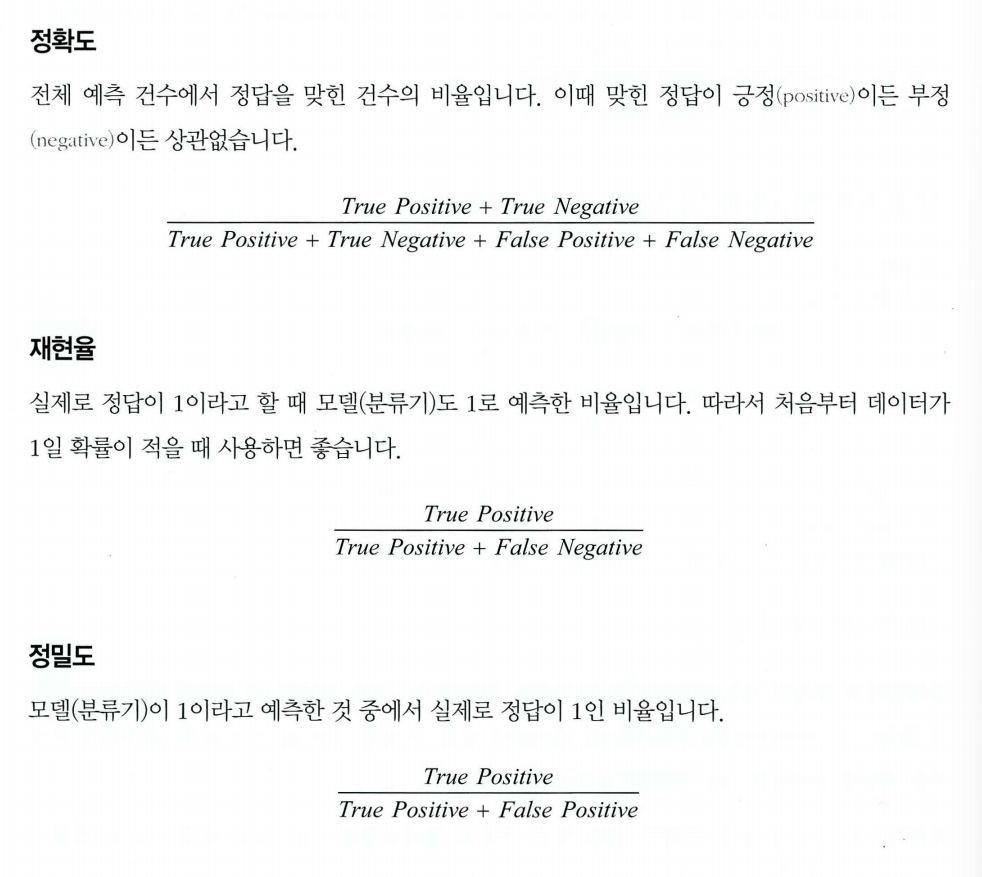

####F1 스코어
- 트레이드 오프 관계
  - 정말도가 높으면 재현율이 낮고, 재현율이 높으면 정밀도가 낮음.
  - 이 문제를 해결하기 위해 정밀도와 재현율의 조화평균을 이용한 것이 F1-스코어 평가
- 조화 평균

  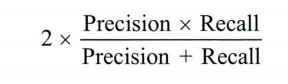